# Deep Learning Models for Inverter Anomaly (Autoencoders)

This notebook implements an Autoencoder model for detecting anomalies in solar inverters. 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# DL models with pytorch
import torch

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Data Loading

In [2]:
# Load the dataset
TRAIN_DATA_PATH = '../../data/datasets/anomaly_detection/train_dataset.csv'
TEST_DATA_PATH = '../../data/datasets/anomaly_detection/test_dataset.csv'

In [3]:
train_df = pd.read_csv(TRAIN_DATA_PATH, parse_dates=['timestamp'])
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'], format='ISO8601', utc=True)

test_df = pd.read_csv(TEST_DATA_PATH, parse_dates=['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'], format='ISO8601', utc=True)

In [4]:
print(f"Dataset shape: {train_df.shape}")
print(f"Date range: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Inverters: {train_df['inverter_id'].unique()}")
print(f"\nData types:")
print(train_df.dtypes)
train_df.head(10)

Dataset shape: (1241782, 20)
Date range: 2026-02-01 19:41:11.671261+00:00 to 2026-03-20 14:08:38.548850+00:00
Inverters: ['B1' 'A2' 'B0' 'B2' 'A3' 'B3' 'C1' 'C2' 'C3' 'C4' 'A1' 'C0' 'C5' 'A0']

Data types:
inverter_id                        object
timestamp             datetime64[ns, UTC]
state                               int64
state.1                             int64
inverter_temp_c                   float64
ac_power_kw                       float64
ac_freq_hz                        float64
dc_power_kw                       float64
dc_voltage_v                      float64
dc_current_a                      float64
healthy_strings                     int64
failed_strings                      int64
active_failures                     int64
amb_temp_c                        float64
module_temp_c                     float64
wind_speed_ms                     float64
wind_dir_deg                      float64
humidity_percent                  float64
poa_irradiance_wm2                floa

,inverter_id,timestamp,state,state.1,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,is_anomaly
0,B1,2026-02-01 19:41:11.671261+00:00,2,2,20.90,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
1,A2,2026-02-01 19:41:11.671261+00:00,2,2,20.37,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
2,B0,2026-02-01 19:41:11.671261+00:00,2,2,20.03,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
3,B2,2026-02-01 19:41:11.671261+00:00,2,2,19.42,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
4,A3,2026-02-01 19:41:11.671261+00:00,2,2,19.59,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
5,B3,2026-02-01 19:41:11.671261+00:00,2,2,19.15,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
6,C1,2026-02-01 19:41:11.671261+00:00,2,2,19.34,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
7,C2,2026-02-01 19:41:11.671261+00:00,2,2,19.32,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
8,C3,2026-02-01 19:41:11.671261+00:00,2,2,20.76,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0
9,C4,2026-02-01 19:41:11.671261+00:00,2,2,20.57,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0,0


In [5]:
print(f"Dataset shape: {test_df.shape}")
print(f"Date range: {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")
print(f"Inverters: {test_df['inverter_id'].unique()}")
print(f"\nData types:")
print(test_df.dtypes)
test_df.head(10)

Dataset shape: (546506, 20)
Date range: 2026-02-01 19:53:54.586707+00:00 to 2026-04-09 11:54:48.353354+00:00
Inverters: ['B0' 'C2' 'A1' 'C1' 'B3' 'B1' 'C3' 'C0' 'C4' 'C5' 'A2' 'A3' 'A0' 'B2']

Data types:
inverter_id                        object
timestamp             datetime64[ns, UTC]
state                               int64
state.1                             int64
inverter_temp_c                   float64
ac_power_kw                       float64
ac_freq_hz                        float64
dc_power_kw                       float64
dc_voltage_v                      float64
dc_current_a                      float64
healthy_strings                     int64
failed_strings                      int64
active_failures                     int64
amb_temp_c                        float64
module_temp_c                     float64
wind_speed_ms                     float64
wind_dir_deg                      float64
humidity_percent                  float64
poa_irradiance_wm2                float

,inverter_id,timestamp,state,state.1,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2,is_anomaly
0,B0,2026-02-01 19:53:54.586707+00:00,2,2,27.91,0.0,0.0,0.0,0.0,0.0,12,0,1,9.84,9.84,1.97,143.2,53.6,0.0,1
1,B0,2026-02-01 19:54:25.437516+00:00,2,2,34.14,0.0,0.0,0.0,0.0,0.0,12,0,1,10.23,10.23,2.00,140.9,53.4,0.0,1
2,B0,2026-02-01 19:55:19.189130+00:00,2,2,30.37,0.0,0.0,0.0,0.0,0.0,12,0,1,10.13,10.13,1.98,140.6,53.9,0.0,1
3,B0,2026-02-01 19:55:57.385155+00:00,2,2,28.98,0.0,0.0,0.0,0.0,0.0,12,0,1,10.13,10.13,1.98,140.6,53.9,0.0,1
4,B0,2026-02-01 19:56:30.586144+00:00,2,2,34.18,0.0,0.0,0.0,0.0,0.0,12,0,1,9.79,9.79,1.90,141.4,54.0,0.0,1
5,B0,2026-02-01 19:57:01.231965+00:00,2,2,34.28,0.0,0.0,0.0,0.0,0.0,12,0,1,9.32,9.32,1.99,140.4,53.3,0.0,1
6,B0,2026-02-01 19:57:31.739231+00:00,2,2,28.57,0.0,0.0,0.0,0.0,0.0,12,0,1,10.00,10.00,2.01,142.2,53.4,0.0,1
7,B0,2026-02-01 19:58:16.621371+00:00,2,2,34.88,0.0,0.0,0.0,0.0,0.0,12,0,1,10.00,10.00,2.01,142.2,53.4,0.0,1
8,B0,2026-02-01 19:58:47.663165+00:00,2,2,32.51,0.0,0.0,0.0,0.0,0.0,12,0,1,10.05,10.05,2.08,142.3,52.7,0.0,1
9,B0,2026-02-01 19:59:25.858488+00:00,2,2,35.09,0.0,0.0,0.0,0.0,0.0,12,0,1,9.72,9.72,2.08,141.9,53.0,0.0,1


In [6]:
# Select a single inverter for modeling (A0 as reference, same as baseline notebook)
INVERTER_ID = 'A0'

train_df_inverter = train_df[train_df['inverter_id'] == INVERTER_ID].copy()
test_df_inverter = test_df[test_df['inverter_id'] == INVERTER_ID].copy()

print(f"Selected inverter: {INVERTER_ID}")
print(f"Train Records: {len(train_df_inverter)}")
print(f"Test Records: {len(test_df_inverter)}")


Selected inverter: A0
Train Records: 89075
Test Records: 38633


## Data Preprocessing

For DL models, we'll:
1. Drop identifier columns (`inverter_id`, `state`, ...)
2. **Remove data leakage columns**
3. Handle missing values from lag features (drop rows with NaN)


In [7]:
label_col = 'is_anomaly'

# Columns that should never be used as model features
drop_cols = ['timestamp', 'inverter_id', 'state', 'is_anomaly']
print(f"Dropping columns: {drop_cols}")

train_model_df = train_df_inverter.drop(columns=drop_cols).copy()
test_model_df = test_df_inverter.drop(columns=drop_cols).copy()

# Keep numeric columns only for autoencoder
numeric_cols = train_model_df.select_dtypes(include=[np.number]).columns.tolist()
train_model_df = train_model_df[numeric_cols].copy()
test_model_df = test_model_df[numeric_cols].copy()

# Handle NaNs from lag/rolling features
train_model_df = train_model_df.replace([np.inf, -np.inf], np.nan).dropna().copy()
test_model_df = test_model_df.replace([np.inf, -np.inf], np.nan).dropna().copy()

print(f"Feature count: {len(numeric_cols)}")
print(f"Train shape after preprocessing: {train_model_df.shape}")
print(f"Test shape after preprocessing: {test_model_df.shape}")
display(train_model_df.head())

Dropping columns: ['timestamp', 'inverter_id', 'state', 'is_anomaly']
Feature count: 16
Train shape after preprocessing: (89075, 16)
Test shape after preprocessing: (38633, 16)


,state.1,inverter_temp_c,ac_power_kw,ac_freq_hz,dc_power_kw,dc_voltage_v,dc_current_a,healthy_strings,failed_strings,active_failures,amb_temp_c,module_temp_c,wind_speed_ms,wind_dir_deg,humidity_percent,poa_irradiance_wm2
13,2,20.85,0.0,0.0,0.0,0.0,0.0,12,0,0,9.97,9.97,2.22,127.9,54.7,0.0
16,2,19.28,0.0,0.0,0.0,0.0,0.0,12,0,0,10.68,10.68,2.14,126.4,55.0,0.0
31,2,19.59,0.0,0.0,0.0,0.0,0.0,12,0,0,10.02,10.02,2.19,125.5,54.4,0.0
48,2,19.25,0.0,0.0,0.0,0.0,0.0,12,0,0,10.03,10.03,2.19,129.0,53.8,0.0
60,2,19.80,0.0,0.0,0.0,0.0,0.0,12,0,0,10.74,10.74,2.32,131.3,52.2,0.0


## Feature Scaling and Tensor Preparation

We standardize train/test using train statistics and create `DataLoader` objects for PyTorch training.

In [8]:
# Standardization with training set statistics
train_mean = train_model_df.mean()
train_std = train_model_df.std().replace(0, 1.0)

X_train = ((train_model_df - train_mean) / train_std).astype(np.float32).values
X_test = ((test_model_df - train_mean) / train_std).astype(np.float32).values

# Build tensors and dataloaders
batch_size = 64
train_tensor = torch.tensor(X_train, dtype=torch.float32)
test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (89075, 16)
X_test shape: (38633, 16)


## Autoencoder Definition and Training

Using device: cuda
Epoch [01/30] - Loss: 0.193786
Epoch [05/30] - Loss: 0.010388
Epoch [10/30] - Loss: 0.009940
Epoch [15/30] - Loss: 0.009693
Epoch [20/30] - Loss: 0.009384
Epoch [25/30] - Loss: 0.004522
Epoch [30/30] - Loss: 0.002878


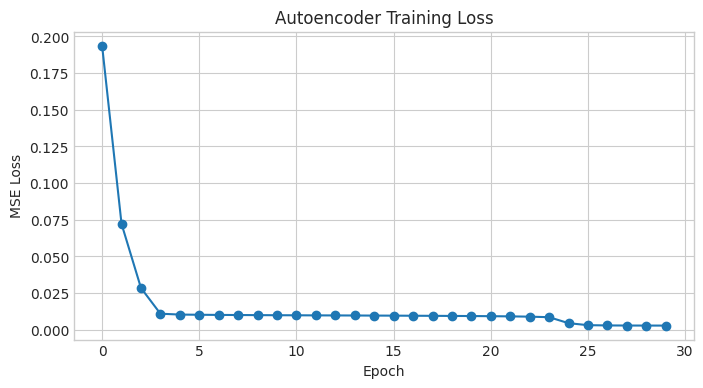

In [9]:
# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class Autoencoder(torch.nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        hidden_dim = max(8, input_dim // 2)
        bottleneck_dim = max(4, input_dim // 4)

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, bottleneck_dim),
            torch.nn.ReLU(),
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(bottleneck_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

input_dim = X_train.shape[1]
model = Autoencoder(input_dim=input_dim).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30
train_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for (batch_x,) in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()

        recon = model(batch_x)
        loss = criterion(recon, batch_x)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{epochs}] - Loss: {epoch_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

## Reconstruction Error and Anomaly Detection

Threshold quantile: 0.9968
Threshold value: 0.063972
Detected anomalies in test: 837 / 38633


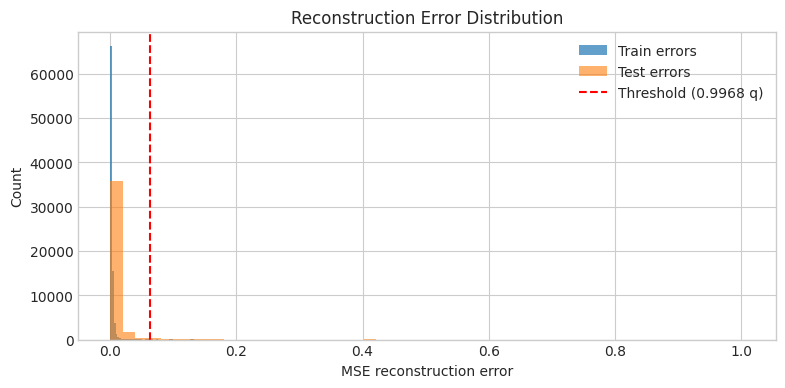

In [29]:
def reconstruction_errors(model, array_x, device):
    model.eval()
    with torch.no_grad():
        x_t = torch.tensor(array_x, dtype=torch.float32).to(device)
        x_hat = model(x_t)
        err = torch.mean((x_hat - x_t) ** 2, dim=1).cpu().numpy()
    return err

train_errors = reconstruction_errors(model, X_train, device)
test_errors = reconstruction_errors(model, X_test, device)

# Simple threshold: high quantile of train reconstruction errors
threshold_quantile = 0.9968
threshold = float(np.quantile(train_errors, threshold_quantile))
test_pred_anomaly = (test_errors > threshold).astype(int)

print(f"Threshold quantile: {threshold_quantile}")
print(f"Threshold value: {threshold:.6f}")
print(f"Detected anomalies in test: {test_pred_anomaly.sum()} / {len(test_pred_anomaly)}")

plt.figure(figsize=(9, 4))
plt.hist(train_errors, bins=50, alpha=0.7, label='Train errors')
plt.hist(test_errors, bins=50, alpha=0.6, label='Test errors')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold_quantile:.4f} q)')
plt.title('Reconstruction Error Distribution')
plt.xlabel('MSE reconstruction error')
plt.ylabel('Count')
plt.legend()
plt.show()

Confusion Matrix:
[[37796   380]
 [    0   457]]
Precision: 0.5460
Recall: 1.0000
F1-score: 0.7063


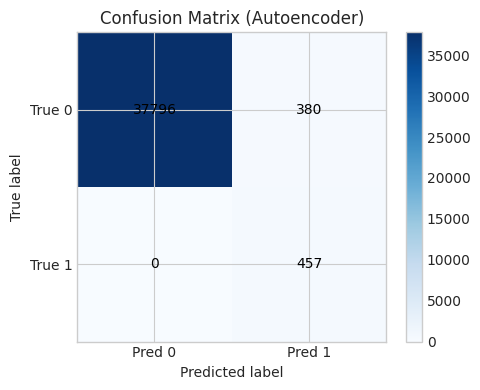

Last timestamp in test set: 2026-04-09 11:50:40.416762+00:00
Window start (last 2 days): 2026-04-07 11:50:40.416762+00:00
Predicted anomalies in last 2 days: 72 / 3833


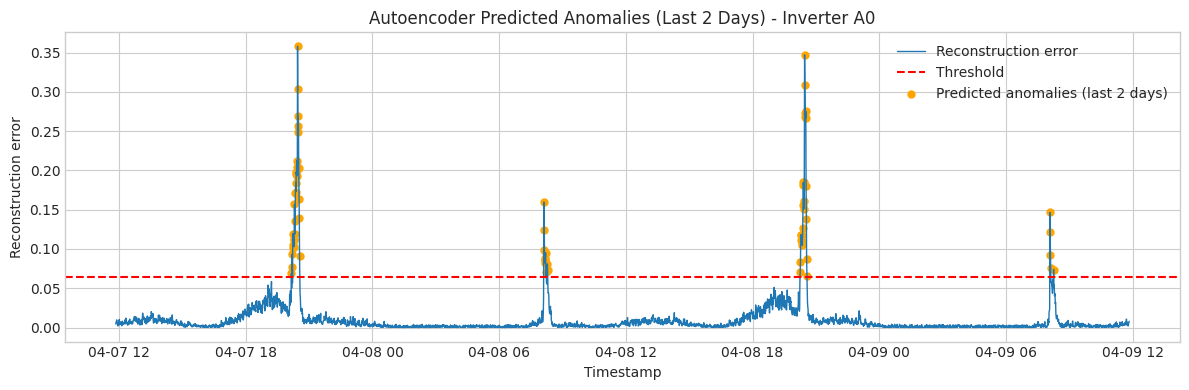

,timestamp,reconstruction_error,pred_anomaly
492828,2026-04-07 11:50:52.982540+00:00,0.004376,0
492846,2026-04-07 11:51:48.777302+00:00,0.007035,0
492860,2026-04-07 11:52:28.705084+00:00,0.007004,0
492876,2026-04-07 11:53:21.037367+00:00,0.009741,0
492891,2026-04-07 11:54:10.574617+00:00,0.005381,0
492903,2026-04-07 11:54:47.457176+00:00,0.005139,0
492919,2026-04-07 11:55:46.463167+00:00,0.004348,0
492940,2026-04-07 11:56:45.392607+00:00,0.002011,0
492952,2026-04-07 11:57:29.061934+00:00,0.002880,0
492965,2026-04-07 11:58:10.248684+00:00,0.006956,0


In [ ]:
# Build a result dataframe aligned with the cleaned test subset
test_eval_df = test_df_inverter.loc[test_model_df.index, ['timestamp']].copy()
test_eval_df['reconstruction_error'] = test_errors
test_eval_df['pred_anomaly'] = test_pred_anomaly

y_true = test_df_inverter.loc[test_model_df.index, label_col].astype(int).values
y_pred = test_pred_anomaly

tp = int(((y_true == 1) & (y_pred == 1)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

conf_matrix = np.array([[tn, fp], [fn, tp]])
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

plt.figure(figsize=(5, 4))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (Autoencoder)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Pred 0', 'Pred 1'])
plt.yticks(tick_marks, ['True 0', 'True 1'])

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Show predicted anomalies only for the last 2 days of test data
last_timestamp = test_eval_df['timestamp'].max()
window_start = last_timestamp - pd.Timedelta(days=2)
last_2d_df = test_eval_df[test_eval_df['timestamp'] >= window_start].copy()
last_2d_anomalies = last_2d_df[last_2d_df['pred_anomaly'] == 1]

print(f"Last timestamp in test set: {last_timestamp}")
print(f"Window start (last 2 days): {window_start}")
print(f"Predicted anomalies in last 2 days: {len(last_2d_anomalies)} / {len(last_2d_df)}")

plt.figure(figsize=(12, 4))
plt.plot(last_2d_df['timestamp'], last_2d_df['reconstruction_error'], label='Reconstruction error', linewidth=1)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')

plt.scatter(
    last_2d_anomalies['timestamp'],
    last_2d_anomalies['reconstruction_error'],
    color='orange',
    s=25,
    label='Predicted anomalies (last 2 days)'
)

plt.title(f'Autoencoder Predicted Anomalies (Last 2 Days) - Inverter {INVERTER_ID}')
plt.xlabel('Timestamp')
plt.ylabel('Reconstruction error')
plt.legend()
plt.tight_layout()
plt.show()

last_2d_df.head(10)